# Exercise 5 [SOLUTION]: GAE, TRPO and PPO

**From last session:** solved REINFORCE and Actor-Critic with 1-step TD baselines

**Today:** Generalized Advantage Estimation (GAE) | Trust-region methods (TRPO) | Proximal Policy Optimization (PPO)

**Goal:** reuse last session's solved baselines, then compare them against the advanced policy-gradient methods you implement in this notebook.

> The REINFORCE and Actor-Critic code below comes from the previous exercise session. Treat it as reference code for comparison, not as today's exercise.


## Setup & Imports

In [1]:
!pip install gymnasium[classic-control] torch matplotlib numpy tqdm -q

zsh:1: no matches found: gymnasium[classic-control]


In [2]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.distributions import Categorical
from tqdm.notebook import tqdm
import gymnasium as gym, numpy as np, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [3]:
torch.manual_seed(42); np.random.seed(42)

def smooth(x, w=20): return np.convolve(x, np.ones(w)/w, mode='valid')
def plot_rewards(r, title, w=20):
    plt.figure(figsize=(9,3)); plt.plot(r, alpha=0.3, label='raw')
    if len(r)>=w: plt.plot(range(w-1,len(r)), smooth(r,w), label=f'smoothed({w})')
    plt.xlabel('Episode'); plt.ylabel('Return'); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

print('Setup complete')


Setup complete


---
# From Last Session: Reference Baselines

The next two code blocks are the **solved implementations from the previous exercise session**. We include them here so that everyone starts Exercise 5 with the same baselines.

Run them top-to-bottom before running GAE/TRPO/PPO. Later comparison plots will use:
- `reinforce_rewards` from REINFORCE
- `ac_rewards` from Actor-Critic with 1-step TD


---
## REINFORCE Baseline

> Solved in the previous exercise session. We keep it here for comparison purpose.

REINFORCE (Williams 1992) is the simplest policy gradient algorithm:

1. Collect full episode under $\pi_\theta$
2. Compute returns $G_t = \sum_{t'\ge t}\gamma^{t'-t}r_{t'}$
3. Update: $\theta \leftarrow \theta + \alpha\sum_t \nabla_\theta\log\pi_\theta(a_t|s_t)\cdot G_t$

Loss (minimised): $\mathcal{L} = -\sum_t \log\pi_\theta(a_t|s_t)\cdot(G_t - b)$

Properties: ✓ Unbiased | ✗ High variance | ✗ Sample-inefficient


### ⚠️ Fix note: scalar log-probabilities

`PolicyNet.act()` returns `dist.log_prob(a).squeeze(0)`. This makes `torch.stack(log_probs)` a `[T]` tensor, matching the `[T]` return tensor. Without the squeeze, PyTorch broadcasts `[T, 1] * [T]` into `[T, T]`, which is not the REINFORCE objective.

This is a shape fix; the intended REINFORCE formula is unchanged.


Training previous-session REINFORCE baseline:   0%|          | 0/500 [00:00<?, ?it/s]

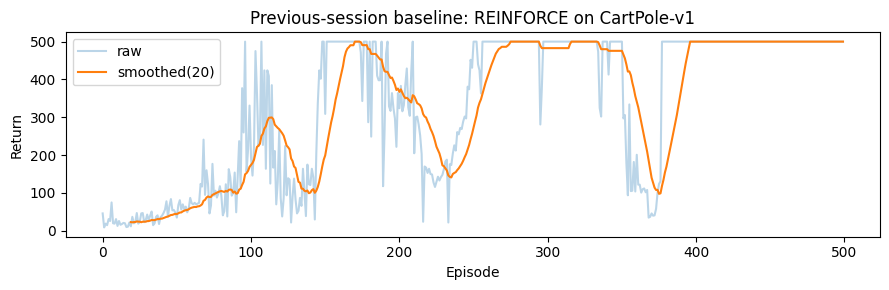

In [4]:
# Previous session solution: REINFORCE with return normalisation
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_act, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.ReLU(),
            nn.Linear(h, h),       nn.ReLU(),
            nn.Linear(h, n_act)
        )
    def forward(self, x): return self.net(x)
    def act(self, s):
        s = torch.FloatTensor(s).unsqueeze(0).to(device)
        dist = Categorical(logits=self.forward(s))
        a = dist.sample()
        return a.item(), dist.log_prob(a).squeeze(0)

def compute_returns(rewards, gamma=0.99):
    G, returns = 0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

def reinforce_update(policy, opt, log_probs, rewards, gamma=0.99):
    returns = torch.FloatTensor(compute_returns(rewards, gamma)).to(device)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    loss = -(torch.stack(log_probs) * returns).mean()
    opt.zero_grad(); loss.backward(); opt.step()

def train_reinforce(n_ep=500, desc='Training previous-session REINFORCE baseline'):
    env = gym.make('CartPole-v1')
    policy = PolicyNet(4, 2).to(device)
    opt = optim.Adam(policy.parameters(), lr=3e-3)
    all_r = []
    pbar = tqdm(range(n_ep), desc=desc)
    for ep in pbar:
        s, _ = env.reset(); lps, rs, done = [], [], False
        while not done:
            a, lp = policy.act(s)
            s, r, te, tr, _ = env.step(a); done = te or tr
            lps.append(lp); rs.append(r)
        reinforce_update(policy, opt, lps, rs)
        all_r.append(sum(rs))
        pbar.set_postfix(mean_100=f'{np.mean(all_r[-100:]):.1f}')
    env.close(); return all_r, policy

reinforce_rewards, reinforce_policy = train_reinforce()
plot_rewards(reinforce_rewards, 'Previous-session baseline: REINFORCE on CartPole-v1')


---
## Actor-Critic TD Baseline

> Solved in the previous exercise session. We keep it here for comparison purpose.

**Advantage function:** $A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$  
How much better is action $a$ compared to the average?

**1-step TD error** as advantage estimate:
$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

**Actor-Critic** maintains two components:
- **Actor** $\pi_\theta(a|s)$ — acts in the environment
- **Critic** $V_\phi(s)$ — estimates state values

Properties: ✓ Lower variance than REINFORCE | ✗ Introduces bias from approximate $V$


### ⚠️ Fix note: actor-critic output shapes

`ActorCritic.act()` now returns a scalar log-probability and a squeezed value estimate. This keeps later actor-critic losses aligned as one scalar contribution per environment step.

The TD actor-critic update itself is still the same: policy loss from the TD error, value loss from squared TD error, plus entropy regularization.


Training previous-session Actor-Critic TD baseline:   0%|          | 0/500 [00:00<?, ?it/s]

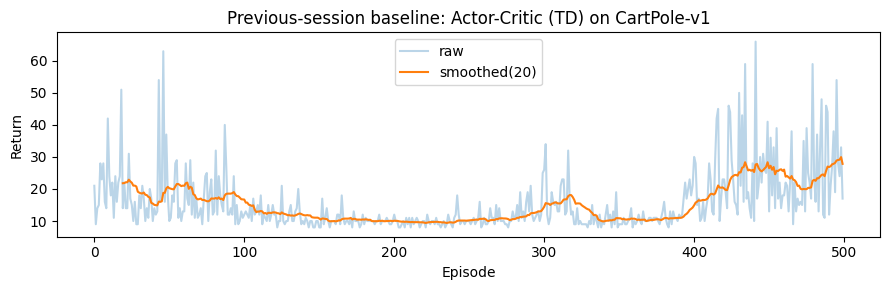

In [5]:
# Previous session solution: Actor-Critic with 1-step TD
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_act, h=128):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(obs_dim, h), nn.ReLU())
        self.actor  = nn.Sequential(nn.Linear(h, h), nn.ReLU(), nn.Linear(h, n_act))
        self.critic = nn.Sequential(nn.Linear(h, h), nn.ReLU(), nn.Linear(h, 1))
    def forward(self, x):
        f = self.shared(x)
        return self.actor(f), self.critic(f)
    def act(self, s):
        s = torch.FloatTensor(s).unsqueeze(0).to(device)
        logits, v = self.forward(s)
        dist = Categorical(logits=logits); a = dist.sample()
        return a.item(), dist.log_prob(a).squeeze(0), v.squeeze(-1)

def train_actor_critic(n_ep=500, gamma=0.99, ent_coef=0.01, val_coef=0.5,
                       desc='Training previous-session Actor-Critic TD baseline'):
    env = gym.make('CartPole-v1')
    model = ActorCritic(4, 2).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)
    all_r = []
    pbar = tqdm(range(n_ep), desc=desc)
    for ep in pbar:
        s, _ = env.reset(); done = False
        a_losses, c_losses, ents = [], [], []
        ep_r = 0
        while not done:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            logits, v = model(s_t)
            dist = Categorical(logits=logits); a = dist.sample()
            s2, r, te, tr, _ = env.step(a.item()); done = te or tr
            with torch.no_grad():
                _, v2 = model(torch.FloatTensor(s2).unsqueeze(0).to(device))
                v2 = torch.zeros(1, 1).to(device) if done else v2
            delta = r + gamma * v2 - v
            a_losses.append(-dist.log_prob(a) * delta.detach())
            c_losses.append(delta.pow(2))
            ents.append(dist.entropy())
            s = s2; ep_r += r
        loss = (torch.stack(a_losses).mean()
                + val_coef * torch.stack(c_losses).mean()
                - ent_coef * torch.stack(ents).mean())
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5); opt.step()
        all_r.append(ep_r)
        pbar.set_postfix(mean_100=f'{np.mean(all_r[-100:]):.1f}')
    env.close(); return all_r, model

ac_rewards, ac_model = train_actor_critic()
plot_rewards(ac_rewards, 'Previous-session baseline: Actor-Critic (TD) on CartPole-v1')


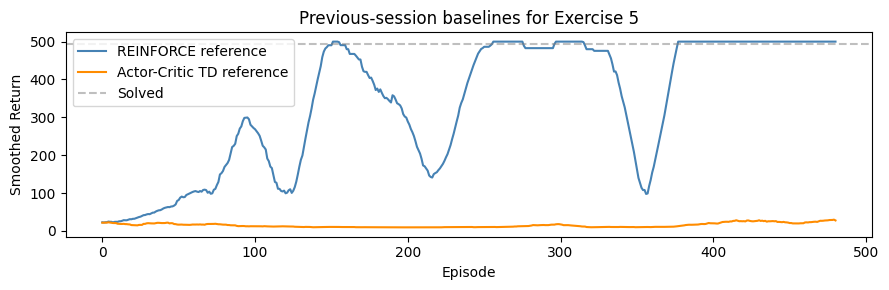

In [6]:
# Quick check: previous-session baselines
plt.figure(figsize=(9,3))
plt.plot(smooth(reinforce_rewards), label='REINFORCE reference', color='steelblue')
plt.plot(smooth(ac_rewards), label='Actor-Critic TD reference', color='darkorange')
plt.axhline(495, color='gray', ls='--', alpha=0.5, label='Solved')
plt.xlabel('Episode'); plt.ylabel('Smoothed Return')
plt.title('Previous-session baselines for Exercise 5')
plt.legend(); plt.tight_layout(); plt.show()


---
# Part 1 - Generalized Advantage Estimation (GAE)

## Theory

Each n-step estimator trades bias for variance:

| Estimator | Bias | Variance |
|-----------|------|----------|
| 1-step TD $\delta_t$ | High | Low |
| Monte Carlo $G_t-V(s_t)$ | Low | High |

**GAE** (Schulman et al. 2016) takes an exponentially-weighted average over all n-step estimators:
$$\hat{A}_t^{\text{GAE}(\gamma,\lambda)} = \sum_{l=0}^{\infty}(\gamma\lambda)^l\delta_{t+l}$$

Efficient recursive computation (backwards):
$$\hat{A}_t = \delta_t + \gamma\lambda\,\hat{A}_{t+1}$$

- $\lambda=0$: pure 1-step TD (low variance, high bias)
- $\lambda=1$: full Monte Carlo (low bias, high variance)
- $\lambda\in[0.90,0.97]$: best in practice


### ⚠️ Fix note: explicit next-state values for GAE

`compute_gae()` now accepts optional `next_values`. This lets rollout-based methods provide the correct `V(s_{t+1})` for each transition, even when a rollout crosses episode reset boundaries.

If `next_values` is omitted, the function keeps the original behavior and uses `values[t+1]`, which is fine for the simple visualization and single-episode cases.


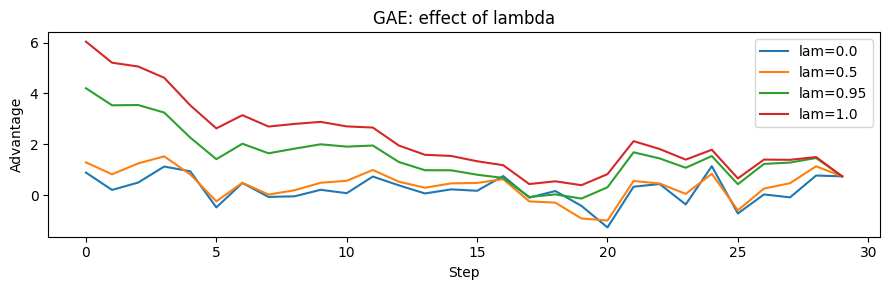

In [7]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95, next_values=None):
    """
    rewards, dones: lists of length T
    values:         list of length T+1, or length T when next_values is provided
    next_values:    optional list of length T with V(s_{t+1}) for each transition
    Returns advantages and returns (advantages + values).
    """
    T = len(rewards)
    values_t = torch.as_tensor(values[:T], dtype=torch.float32)
    if next_values is None:
        next_values_t = torch.as_tensor(values[1:T+1], dtype=torch.float32)
    else:
        next_values_t = torch.as_tensor(next_values, dtype=torch.float32)
    advs = torch.zeros(T)
    gae  = 0.0
    for t in reversed(range(T)):
        mask = 1.0 - dones[t]

        delta = rewards[t] + gamma * next_values_t[t] * mask - values_t[t]

        gae = delta + gamma * lam * gae * mask

        advs[t] = gae

    returns = advs + values_t
    return advs, returns

# Visualise: how lambda shapes the advantage
T = 30; np.random.seed(0)
rs = np.random.randn(T)*0.5; vs = np.zeros(T+1); ds = np.zeros(T); ds[-1]=1
plt.figure(figsize=(9,3))
for lam in [0.0, 0.5, 0.95, 1.0]:
    a, _ = compute_gae(rs, vs, ds, lam=lam)
    plt.plot(a.numpy(), label=f'lam={lam}')
plt.xlabel('Step'); plt.ylabel('Advantage')
plt.title('GAE: effect of lambda'); plt.legend(); plt.tight_layout(); plt.show()


### Extension: Lambda sweep on CartPole

Train Actor-Critic with GAE for different $\lambda$ values and compare final performance.


### ⚠️ Fix note: AC-GAE actor and critic losses

The AC-GAE loop now stores scalar log-probabilities, preventing the `[T, 1] * [T] -> [T, T]` broadcasting bug in the actor loss.

It also stores value predictions twice: detached numbers for computing GAE, and live tensors for the critic loss. This means the critic loss now backpropagates into the value head instead of comparing returns to detached Python floats.


GAE lambda sweep:   0%|          | 0/3 [00:00<?, ?it/s]

Training AC-GAE lambda=0.0:   0%|          | 0/300 [00:00<?, ?it/s]

Training AC-GAE lambda=0.95:   0%|          | 0/300 [00:00<?, ?it/s]

Training AC-GAE lambda=1.0:   0%|          | 0/300 [00:00<?, ?it/s]

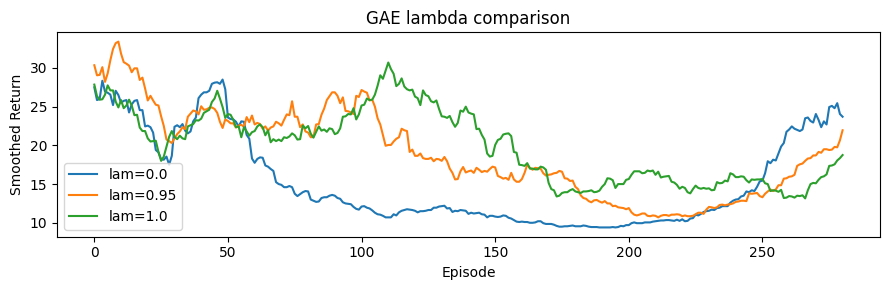

In [8]:
# Actor-Critic with GAE — training loop
def train_ac_gae(n_ep=300, gamma=0.99, lam=0.95, desc=None):
    env = gym.make('CartPole-v1')
    model = ActorCritic(4, 2).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)
    all_r = []
    pbar = tqdm(range(n_ep), desc=desc or f'Training AC-GAE lambda={lam}')
    for ep in pbar:
        s, _ = env.reset(); lps, rs, vs, v_preds, ds, done = [], [], [], [], [], False
        while not done:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            logits, v = model(s_t)
            dist = Categorical(logits=logits); a = dist.sample()
            s2, r, te, tr, _ = env.step(a.item()); done = te or tr
            lps.append(dist.log_prob(a).squeeze(0)); rs.append(r)
            vs.append(v.item()); v_preds.append(v.squeeze()); ds.append(float(te)); s = s2
        with torch.no_grad():
            _, vf = model(torch.FloatTensor(s).unsqueeze(0).to(device))
        vs.append(vf.item())
        advs, rets = compute_gae(rs, vs, ds, gamma, lam)
        advs = ((advs - advs.mean()) / (advs.std()+1e-8)).to(device)
        value_preds = torch.stack(v_preds).to(device)
        loss = (-(torch.stack(lps) * advs.detach()).mean()
                + 0.5 * F.mse_loss(value_preds, rets.to(device)))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5); opt.step()
        all_r.append(sum(rs))
        pbar.set_postfix(mean_50=f'{np.mean(all_r[-50:]):.1f}')
    env.close(); return all_r

plt.figure(figsize=(9,3))
for lam in tqdm([0.0, 0.95, 1.0], desc='GAE lambda sweep'):
    torch.manual_seed(42)
    r = train_ac_gae(lam=lam)
    plt.plot(smooth(r), label=f'lam={lam}')
plt.xlabel('Episode'); plt.ylabel('Smoothed Return')
plt.title('GAE lambda comparison'); plt.legend(); plt.tight_layout(); plt.show()


---
# Part 2 - Trust-Region Methods & TRPO

## Theory

Naive gradient ascent can take a step so large the new policy is outside the region where
collected samples are valid, causing **catastrophic collapse**.

**TRPO** (Schulman et al. 2015) guarantees monotonic improvement by solving:
$$\max_\theta\;\mathbb{E}_t\!\left[\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}\hat{A}_t\right]
\quad\text{s.t.}\quad
\mathbb{E}_t[\text{KL}(\pi_{\theta_{\text{old}}}\|\pi_\theta)]\le\delta$$

The ratio $r_t(\theta)=\pi_\theta/\pi_{\theta_{\text{old}}}$ is the **importance-sampling (IS) ratio** —
it lets us reuse old data to evaluate a new policy.

Full TRPO needs conjugate-gradient + Hessian-vector products (expensive).  
Here we implement the simpler **KL-penalty version**: $\max\;L^{\text{CPI}} - \beta\cdot\text{KL}$,  
and adapt $\beta$ to keep KL near a target $\delta$.


### ⚠️ Fix note: TRPO rollout bootstrap values

The TRPO/KL rollout now records one `next_value` per transition and passes those values into GAE. This avoids using the value of a reset state as the bootstrap target for the previous episode.

The GAE mask uses true termination, while environment reset still happens on either termination or truncation.


In [9]:
def kl_divergence(logits_old, logits_new):
    """Mean KL(pi_old || pi_new) for discrete distributions."""
    p = F.softmax(logits_old, -1)
    return (p * (F.log_softmax(logits_old,-1) - F.log_softmax(logits_new,-1))).sum(-1).mean()

def collect_rollout(env, model, n_steps=1024):
    states, actions, rewards, values, next_values, log_probs, dones = [], [], [], [], [], [], []
    s, _ = env.reset()
    for _ in range(n_steps):
        s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
        with torch.no_grad(): logits, v = model(s_t)
        dist = Categorical(logits=logits); a = dist.sample()
        s2, r, te, tr, _ = env.step(a.item()); done = te or tr
        with torch.no_grad():
            if te:
                next_v = 0.0
            else:
                _, v_next = model(torch.FloatTensor(s2).unsqueeze(0).to(device))
                next_v = v_next.item()
        states.append(s); actions.append(a.item()); rewards.append(r)
        values.append(v.item()); next_values.append(next_v); log_probs.append(dist.log_prob(a).item())
        dones.append(float(te)); s = s2 if not done else env.reset()[0]
    return states, actions, rewards, values, next_values, log_probs, dones

def train_trpo_kl(n_updates=40, n_steps=1024, kl_target=0.01, beta=1.0, n_epochs=10,
                  desc='Training TRPO (KL-penalty)'):
    env = gym.make('CartPole-v1')
    model = ActorCritic(4, 2).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)
    all_r = []
    pbar = tqdm(range(n_updates), desc=desc)
    for upd in pbar:
        states, actions, rewards, vals, next_vals, old_lps, dones = collect_rollout(env, model, n_steps)
        advs, rets = compute_gae(rewards, vals, dones, next_values=next_vals)
        advs = ((advs-advs.mean())/(advs.std()+1e-8)).to(device)
        s_t = torch.FloatTensor(np.array(states)).to(device)
        a_t = torch.LongTensor(actions).to(device)
        lp_old = torch.FloatTensor(old_lps).to(device)
        with torch.no_grad(): old_logits, _ = model(s_t)
        for _ in range(n_epochs):
            logits, vs = model(s_t)
            ratio = (Categorical(logits=logits).log_prob(a_t) - lp_old).exp()
            kl    = kl_divergence(old_logits, logits)
            loss  = -(ratio * advs).mean() + beta*kl + 0.5*F.mse_loss(vs.squeeze(), rets.to(device))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5); opt.step()
        with torch.no_grad():
            final_kl = kl_divergence(old_logits, model(s_t)[0]).item()
        beta = beta*2 if final_kl > 1.5*kl_target else (beta/2 if final_kl < 0.5*kl_target else beta)
        all_r.append(sum(rewards))
        pbar.set_postfix(reward=f'{sum(rewards):.0f}', kl=f'{final_kl:.4f}', beta=f'{beta:.3f}')
    env.close(); return all_r

trpo_rewards = train_trpo_kl()


Training TRPO (KL-penalty):   0%|          | 0/40 [00:00<?, ?it/s]

---
# Part 3 - PPO (Proximal Policy Optimization)

## Theory

PPO (Schulman et al. 2017) achieves TRPO-level performance with plain first-order gradients
by **clipping** the IS ratio instead of constraining KL:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\!\left[\min\!\left(r_t\hat{A}_t,\;
\text{clip}(r_t,1{-}\epsilon,1{+}\epsilon)\hat{A}_t\right)\right]$$

The `min` always takes the **pessimistic** bound:
- $A>0$: don't increase $\pi$ by more than $1+\epsilon$
- $A<0$: don't decrease $\pi$ by more than $1-\epsilon$

Full objective:
$$L^{\text{PPO}} = L^{\text{CLIP}} - c_1 L^{\text{VF}} + c_2 H[\pi]$$

**PPO training loop:** collect $N$ steps -> compute GAE -> optimise for $K$ epochs on mini-batches -> repeat.


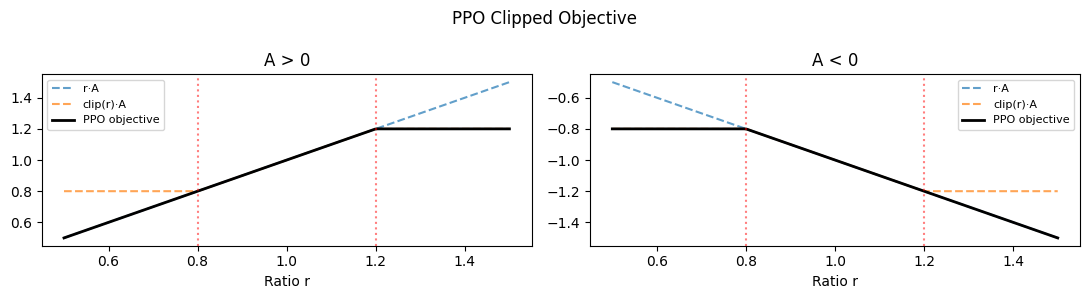

In [10]:
# Visualise the clipped objective
eps = 0.2
ratios = np.linspace(0.5, 1.5, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, A, title in [(axes[0], 1.0, 'A > 0'), (axes[1], -1.0, 'A < 0')]:
    raw     = ratios * A
    clipped = np.clip(ratios, 1-eps, 1+eps) * A
    obj     = np.minimum(raw, clipped)
    ax.plot(ratios, raw,     '--', label='r·A', alpha=0.7)
    ax.plot(ratios, clipped, '--', label='clip(r)·A', alpha=0.7)
    ax.plot(ratios, obj,     'k',  label='PPO objective', lw=2)
    for x in [1-eps, 1+eps]: ax.axvline(x, color='r', ls=':', alpha=0.5)
    ax.set_title(title); ax.legend(fontsize=8); ax.set_xlabel('Ratio r')
plt.suptitle('PPO Clipped Objective'); plt.tight_layout(); plt.show()


### ⚠️ Fix note: PPO ratios and bootstrap values

PPO now stores scalar actions and scalar old log-probabilities. This keeps the importance-sampling ratio shape at `[B]` for a minibatch of size `B`; otherwise `dist.log_prob(actions[b]) - old_lps[b]` can silently broadcast to `[B, B]`.

The rollout also records per-transition `next_values` for GAE, matching the TRPO rollout fix.


Training PPO episodes (device: mps):   0%|          | 0/500 [00:00<?, ?it/s]

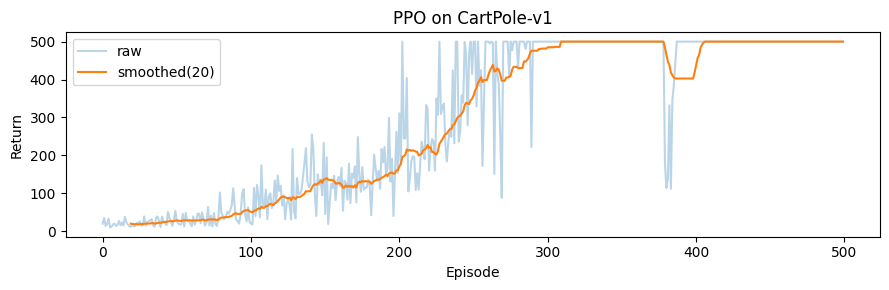

In [11]:
class PPO:
    def __init__(self, obs_dim, n_act, lr=3e-4, gamma=0.99, lam=0.95,
                 eps=0.2, n_epochs=4, batch=64, val_c=0.5, ent_c=0.01):
        self.gamma, self.lam, self.eps = gamma, lam, eps
        self.n_epochs, self.batch = n_epochs, batch
        self.val_c, self.ent_c = val_c, ent_c
        self.model = ActorCritic(obs_dim, n_act).to(device)
        self.opt   = optim.Adam(self.model.parameters(), lr=lr)

    def rollout(self, env, n_steps):
        states, actions, rewards, vals, next_vals, lps, dones = [], [], [], [], [], [], []
        s, _ = env.reset(); ep_rewards, ep_lengths = [], []; cur_r = 0; cur_len = 0
        for _ in range(n_steps):
            s_t = torch.FloatTensor(s).to(device)
            with torch.no_grad(): logits, v = self.model(s_t.unsqueeze(0))
            dist = Categorical(logits=logits); a = dist.sample()
            s2, r, te, tr, _ = env.step(a.item()); done = te or tr
            with torch.no_grad():
                if te:
                    next_v = 0.0
                else:
                    _, v_next = self.model(torch.FloatTensor(s2).unsqueeze(0).to(device))
                    next_v = v_next.squeeze().item()
            states.append(s_t); actions.append(a.squeeze(0)); rewards.append(r)
            vals.append(v.squeeze().item()); next_vals.append(next_v); lps.append(dist.log_prob(a).squeeze(0))
            dones.append(float(te)); cur_r += r; cur_len += 1
            if done: ep_rewards.append(cur_r); ep_lengths.append(cur_len); cur_r = 0; cur_len = 0; s, _ = env.reset()
            else: s = s2
        advs, rets = compute_gae(rewards, vals, dones, self.gamma, self.lam, next_vals)
        advs = ((advs-advs.mean())/(advs.std()+1e-8)).to(device)
        return (torch.stack(states), torch.stack(actions),
                torch.stack(lps).detach(), advs, rets.to(device), ep_rewards, ep_lengths)

    def update(self, states, actions, old_lps, advs, rets):
        T = states.shape[0]; losses = []
        for _ in range(self.n_epochs):
            idx = torch.randperm(T)
            for s in range(0, T, self.batch):
                b = idx[s:s+self.batch]
                logits, vs = self.model(states[b])
                dist = Categorical(logits=logits)

                ratio = (dist.log_prob(actions[b]) - old_lps[b]).exp()
                # Clipped policy loss
                surr = torch.min(ratio * advs[b],
                                 ratio.clamp(1-self.eps, 1+self.eps) * advs[b])

                loss = (-surr.mean()
                        + self.val_c * F.mse_loss(vs.squeeze(), rets[b])
                        - self.ent_c * dist.entropy().mean())

                self.opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.opt.step(); losses.append(loss.item())
        return np.mean(losses)

def train_ppo(n_updates=80, n_steps=512, target_episodes=None, desc=None, **kw):
    env = gym.make('CartPole-v1')
    ppo = PPO(4, 2, **kw)
    all_r, ep_steps = [], []
    total_steps = 0
    if target_episodes is None:
        pbar = tqdm(total=n_updates, desc=desc or f'Training PPO (device: {device})')
    else:
        pbar = tqdm(total=target_episodes, desc=desc or f'Training PPO episodes (device: {device})')
    for upd in range(n_updates):
        s, a, lp, adv, ret, ep_r, ep_len = ppo.rollout(env, n_steps)
        loss = ppo.update(s, a, lp, adv, ret)
        prev_ep_count = len(all_r)
        all_r.extend(ep_r)
        step_cursor = total_steps
        for length in ep_len:
            step_cursor += length
            ep_steps.append(step_cursor)
        total_steps += n_steps
        if target_episodes is None:
            pbar.update(1)
        else:
            pbar.update(min(len(all_r), target_episodes) - prev_ep_count)
        if target_episodes is not None and len(all_r) >= target_episodes:
            all_r = all_r[:target_episodes]
            ep_steps = ep_steps[:target_episodes]
            pbar.set_postfix(mean_ep_reward=f'{np.mean(all_r[-20:]):.1f}', loss=f'{loss:.4f}')
            break
        mean_ep_reward = np.mean(ep_r) if ep_r else 0.0
        pbar.set_postfix(mean_ep_reward=f'{mean_ep_reward:.1f}', loss=f'{loss:.4f}')
    pbar.close()
    env.close(); return all_r, ep_steps, ppo

# PPO trains in fixed-size rollouts, so run enough updates to collect 500 completed episodes.
ppo_rewards, ppo_steps, trained_ppo = train_ppo(n_updates=500, n_steps=512, target_episodes=500)
plot_rewards(ppo_rewards, 'PPO on CartPole-v1')


### Extension: Clip-range ablation


PPO clip-range ablation:   0%|          | 0/3 [00:00<?, ?it/s]

Training PPO eps=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

Training PPO eps=0.2:   0%|          | 0/50 [00:00<?, ?it/s]

Training PPO eps=0.3:   0%|          | 0/50 [00:00<?, ?it/s]

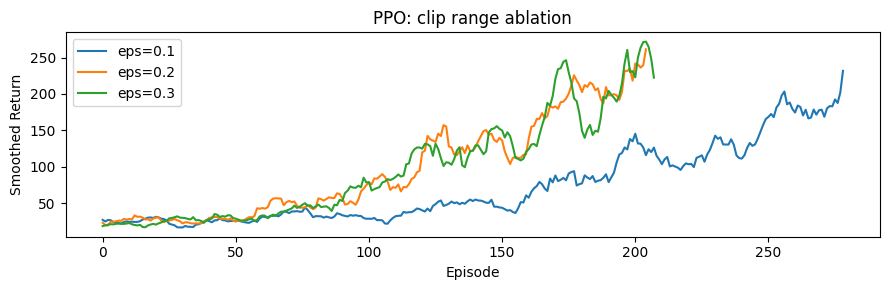

In [12]:
plt.figure(figsize=(9,3))
for eps in tqdm([0.1, 0.2, 0.3], desc='PPO clip-range ablation'):
    torch.manual_seed(42)
    r, _, _ = train_ppo(n_updates=50, n_steps=512, eps=eps, desc=f'Training PPO eps={eps}')
    if len(r) >= 10: plt.plot(smooth(r, 10), label=f'eps={eps}')
plt.xlabel('Episode'); plt.ylabel('Smoothed Return')
plt.title('PPO: clip range ablation'); plt.legend(); plt.tight_layout(); plt.show()


---
# Part 4 - Summary & Comparison

## Algorithm Overview

| Algorithm | Update | Bias | Variance | Stability |
|-----------|--------|------|----------|-----------|
| REINFORCE | Monte Carlo | Low | High | Low |
| Actor-Critic (TD) | 1-step TD | High | Low | Medium |
| Actor-Critic (GAE) | lambda-TD | Tunable | Tunable | Medium |
| TRPO | Trust region | Low | Low | High |
| PPO | Clipped IS | Low | Low | High |

**Rule of thumb:** default to PPO. Use TRPO when guarantees matter. Use REINFORCE for learning.


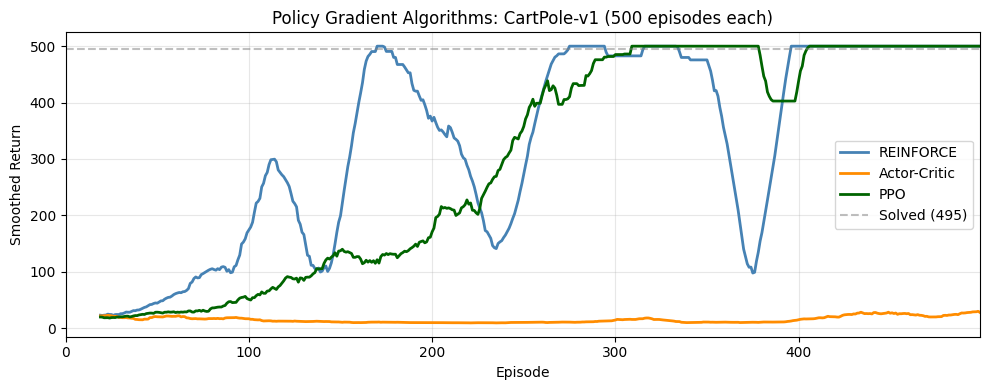

In [13]:
def plot_smoothed_episodes(rewards, label, color, n=None, w=20):
    if n is not None:
        rewards = rewards[:n]
    if len(rewards) < w:
        return
    x = np.arange(w-1, len(rewards))
    plt.plot(x, smooth(rewards, w), label=label, color=color, lw=2)

n_compare = min(500, len(reinforce_rewards), len(ac_rewards), len(ppo_rewards))
plt.figure(figsize=(10,4))
plot_smoothed_episodes(reinforce_rewards, 'REINFORCE', 'steelblue', n=n_compare)
plot_smoothed_episodes(ac_rewards, 'Actor-Critic', 'darkorange', n=n_compare)
plot_smoothed_episodes(ppo_rewards, 'PPO', 'darkgreen', n=n_compare)
plt.axhline(495, color='gray', ls='--', alpha=0.5, label='Solved (495)')
plt.xlim(0, n_compare-1)
plt.xlabel('Episode'); plt.ylabel('Smoothed Return')
plt.title(f'Policy Gradient Algorithms: CartPole-v1 ({n_compare} episodes each)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
